In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("apps.csv")

review = pd.read_csv("user_reviews.csv")

In [3]:
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   str    
 2   Category        9659 non-null   str    
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   str    
 7   Type            9659 non-null   str    
 8   Price           9659 non-null   str    
 9   Content Rating  9659 non-null   str    
 10  Genres          9659 non-null   str    
 11  Last Updated    9659 non-null   str    
 12  Current Ver     9651 non-null   str    
 13  Android Ver     9657 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.0 MB


In [5]:
df.describe()

,Unnamed: 0,Rating,Reviews,Size
count,9659.000000,8196.000000,9.659000e+03,8432.000000
mean,5666.172896,4.173243,2.165926e+05,20.395327
std,3102.362863,0.536625,1.831320e+06,21.827509
min,0.000000,1.000000,0.000000e+00,0.000000
25%,3111.500000,4.000000,2.500000e+01,4.600000
50%,5814.000000,4.300000,9.670000e+02,12.000000
75%,8327.500000,4.500000,2.940100e+04,28.000000
max,10840.000000,5.000000,7.815831e+07,100.000000


In [6]:
df.isnull().sum()

Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [7]:
df['Rating'] = df['Rating'].fillna(
    df['Rating'].mean()
)

df['Size'] = df['Size'].fillna(
    df['Size'].mean()
)

df['Current Ver'] = df['Current Ver'].fillna(
    "Unknown"
)

df['Android Ver'] = df['Android Ver'].fillna(
    "Unknown"
)

In [8]:
df['Installs'] = (
    df['Installs']
    .astype(str)
    .str.replace(',', '')
    .str.replace('+', '')
)

df['Installs'] = pd.to_numeric(
    df['Installs'],
    errors='coerce'
)

In [9]:
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace('$','')
)

df['Price'] = pd.to_numeric(
    df['Price'],
    errors='coerce'
)

In [10]:
top_categories = (
    df['Category']
    .value_counts()
    .head(10)
)

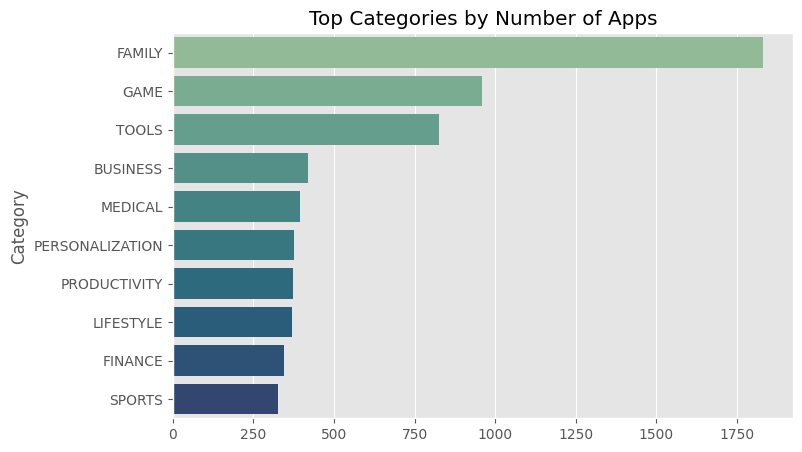

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index,
    hue=top_categories.index,
    palette='crest',
    legend=False
)

plt.title("Top Categories by Number of Apps")

plt.show()

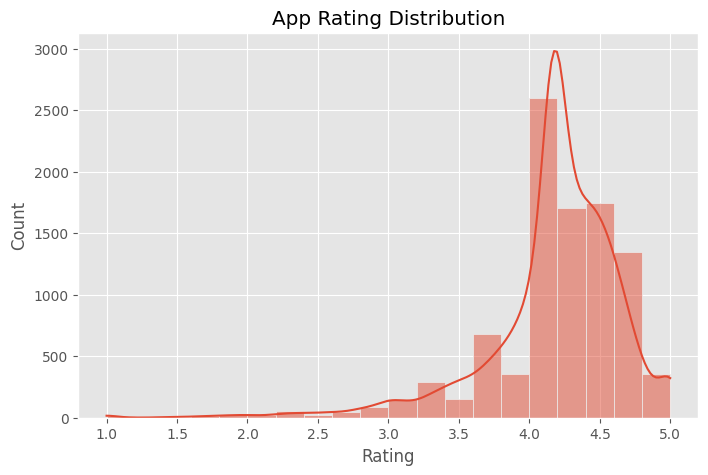

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Rating'],
    bins=20,
    kde=True
)

plt.title("App Rating Distribution")

plt.show()

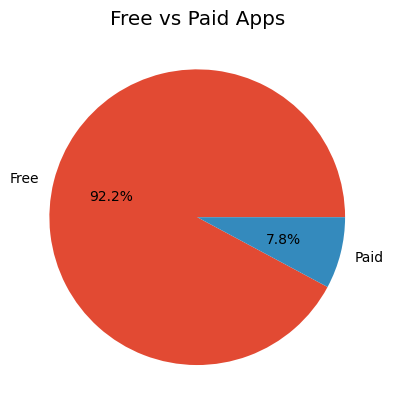

In [13]:
df['Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Free vs Paid Apps")

plt.show()

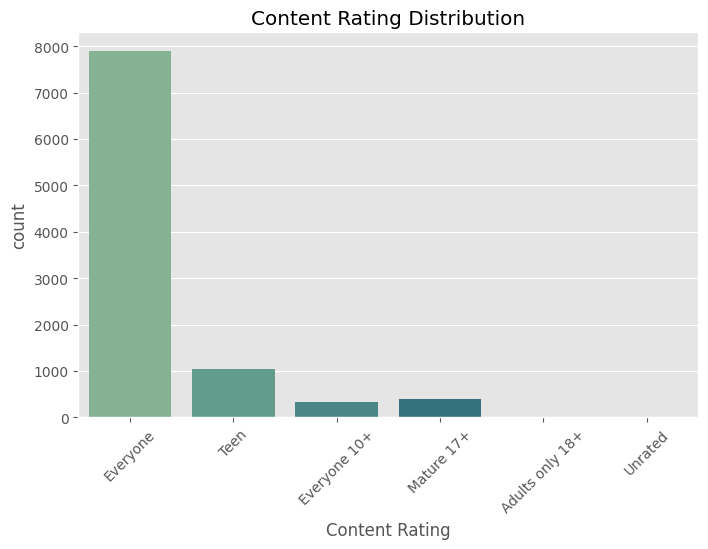

In [14]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Content Rating',
    hue='Content Rating',
    palette='crest',
    legend=False
)

plt.xticks(rotation=45)

plt.title("Content Rating Distribution")

plt.show()

In [15]:
genre = df[
    'Genres'
].value_counts().head(10)

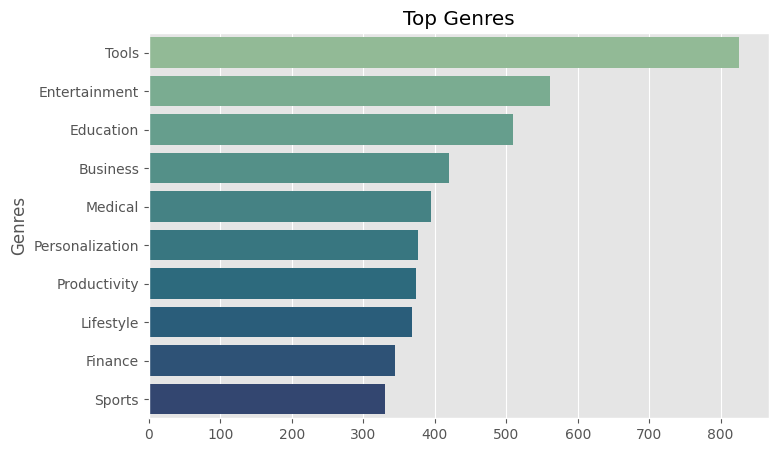

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=genre.values,
    y=genre.index,
    hue=genre.index,
    palette='crest',
    legend=False
)

plt.title("Top Genres")

plt.show()

In [17]:
avg_ratings = (
    df.groupby('Category')
    ['Rating']
    .mean()
    .sort_values(
        ascending=False
    )
    .head(10)
)

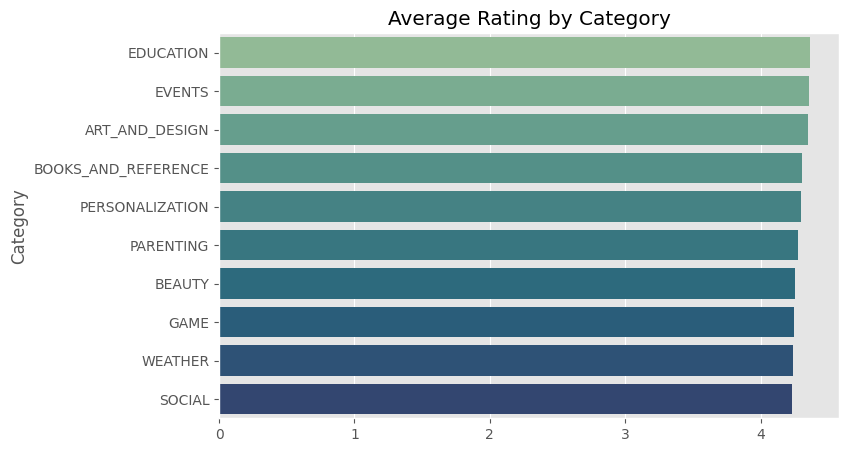

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_ratings.values,
    y=avg_ratings.index,
    hue=avg_ratings.index,
    palette='crest',
    legend=False
)

plt.title("Average Rating by Category")

plt.show()

In [19]:
corr = df[
    ['Rating',
     'Reviews',
     'Installs',
     'Price']
].corr()

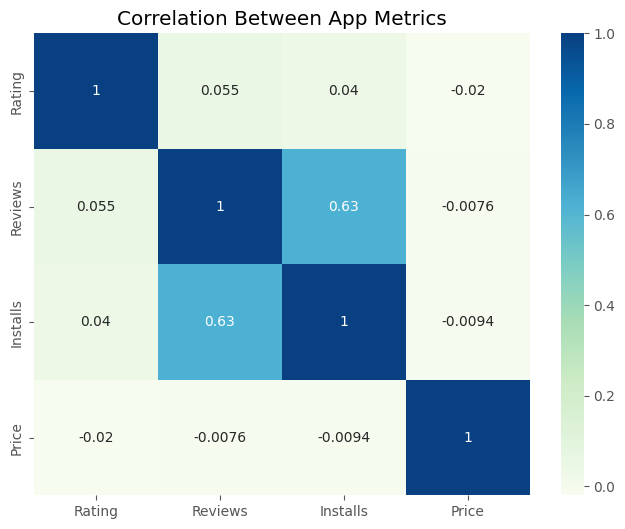

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='GnBu'
)

plt.title(
    "Correlation Between App Metrics"
)

plt.show()

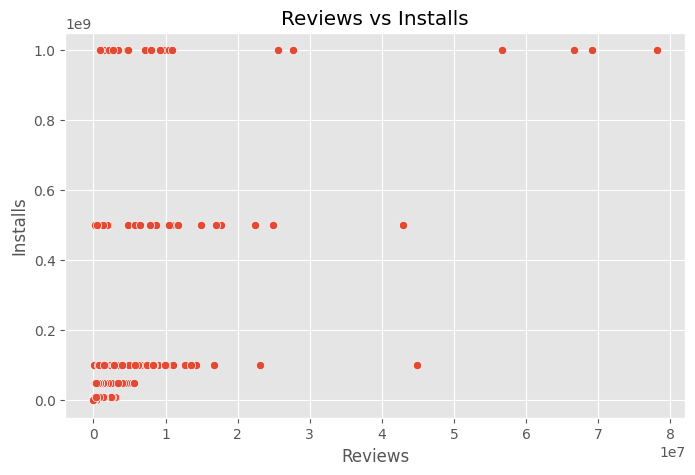

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Reviews',
    y='Installs'
)

plt.title(
    "Reviews vs Installs"
)

plt.show()

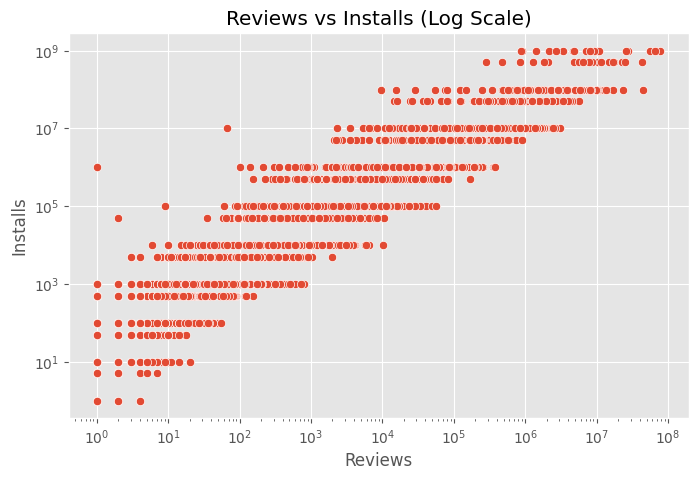

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Reviews',
    y='Installs'
)

plt.xscale('log')
plt.yscale('log')

plt.title(
    "Reviews vs Installs (Log Scale)"
)

plt.show()

In [23]:
top_reviewed = (
    df.sort_values(
        by='Reviews',
        ascending=False
    )
    .head(10)
)

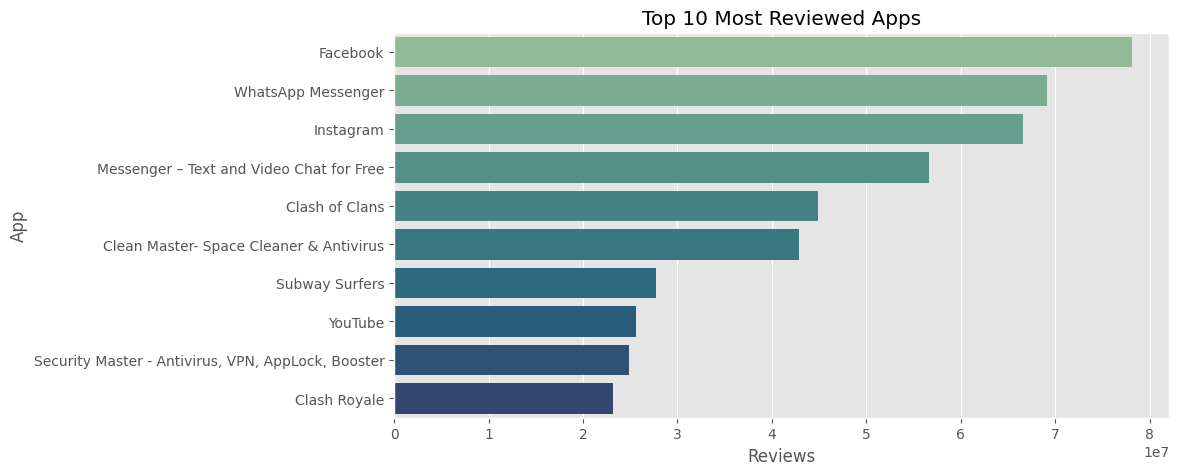

In [24]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_reviewed,
    x='Reviews',
    y='App',
    hue='App',
    palette='crest',
    legend=False
)

plt.title(
    "Top 10 Most Reviewed Apps"
)

plt.show()

In [25]:
top_installs = (
    df.sort_values(
        by='Installs',
        ascending=False
    )
    .head(10)
)

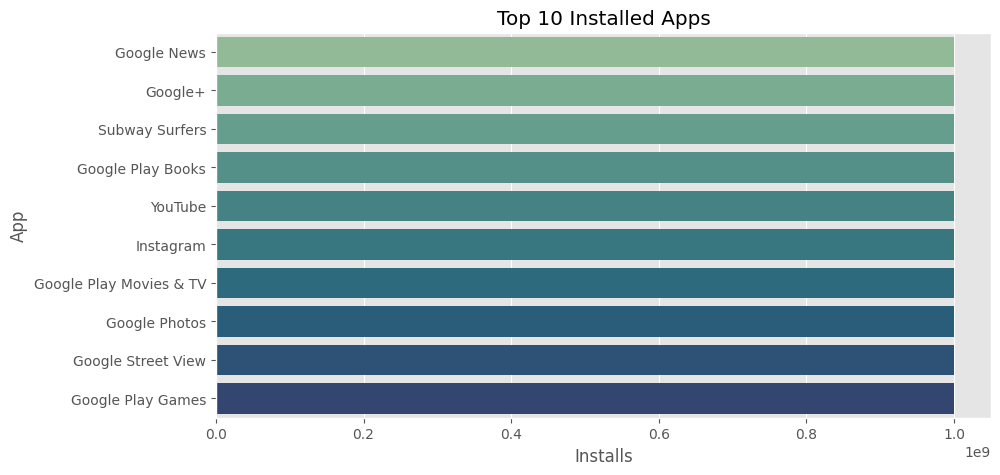

In [26]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_installs,
    x='Installs',
    y='App',
    hue='App',
    palette='crest',
    legend=False
)

plt.title(
    "Top 10 Installed Apps"
)

plt.show()

In [27]:
review = review.dropna()

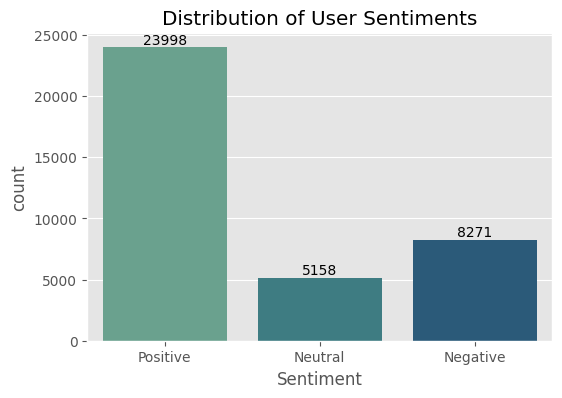

In [28]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=review,
    x='Sentiment',
    hue='Sentiment',
    palette='crest',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Distribution of User Sentiments"
)

plt.show()

In [29]:
sentiment_percentage = (
    review['Sentiment']
    .value_counts(normalize=True)
    * 100
)

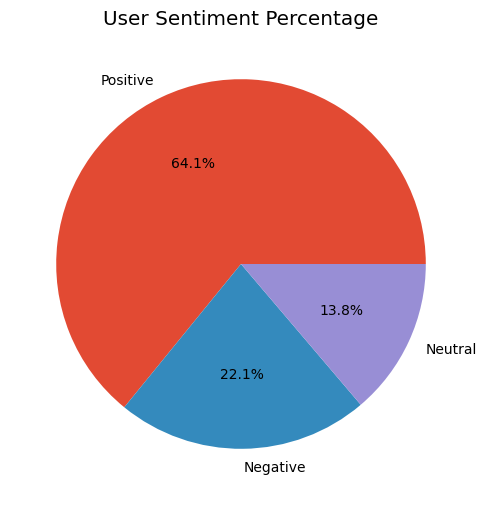

In [30]:
plt.figure(figsize=(6,6))

plt.pie(
    sentiment_percentage,
    labels=sentiment_percentage.index,
    autopct='%1.1f%%'
)

plt.title(
    "User Sentiment Percentage"
)

plt.show()

In [31]:
top_positive = (
    review[
        review['Sentiment']
        == 'Positive'
    ]
    ['App']
    .value_counts()
    .head(10)
)

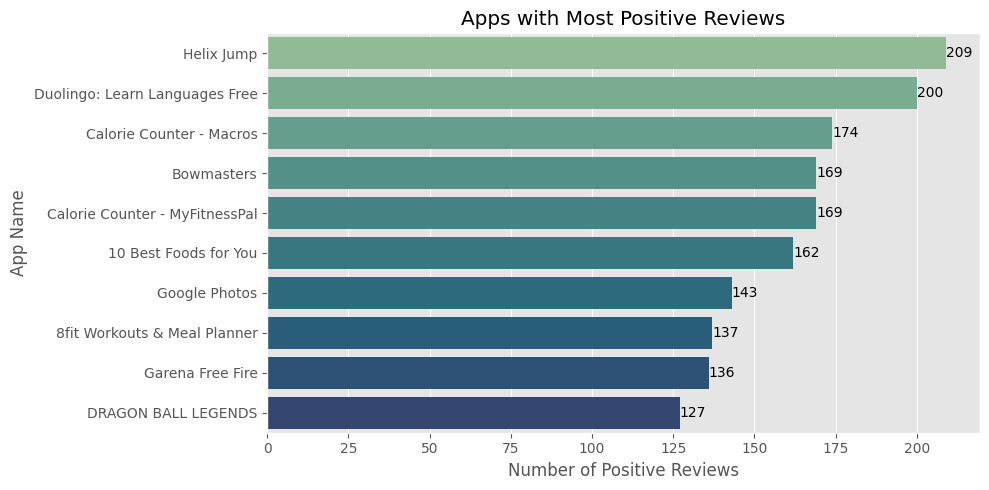

In [38]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=top_positive.values,
    y=top_positive.index,
    hue=top_positive.index,
    palette='crest',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Apps with Most Positive Reviews")
plt.xlabel("Number of Positive Reviews")
plt.ylabel("App Name")

plt.tight_layout()
plt.show()

In [32]:
top_negative = (
    review[
        review['Sentiment']
        == 'Negative'
    ]
    ['App']
    .value_counts()
    .head(10)
)

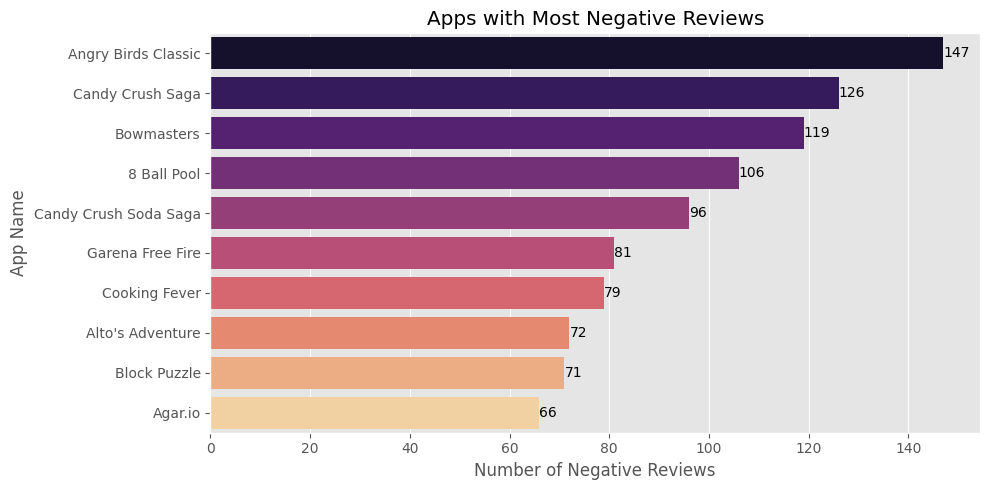

In [39]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=top_negative.values,
    y=top_negative.index,
    hue=top_negative.index,
    palette='magma',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Apps with Most Negative Reviews")
plt.xlabel("Number of Negative Reviews")
plt.ylabel("App Name")

plt.tight_layout()
plt.show()

<Axes: xlabel='Sentiment_Polarity', ylabel='Count'>

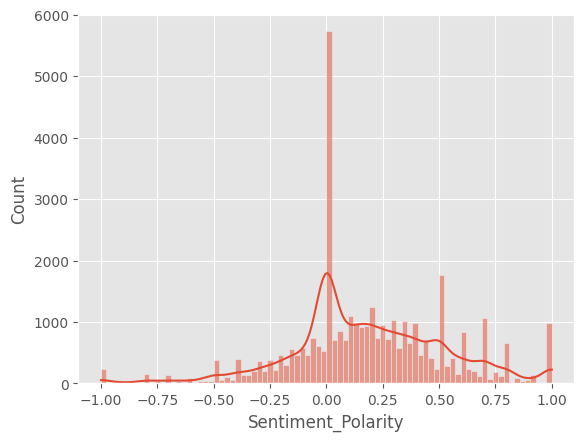

In [33]:
sns.histplot(
    review[
        'Sentiment_Polarity'
    ],
    kde=True
)

<Axes: xlabel='Sentiment_Subjectivity', ylabel='Count'>

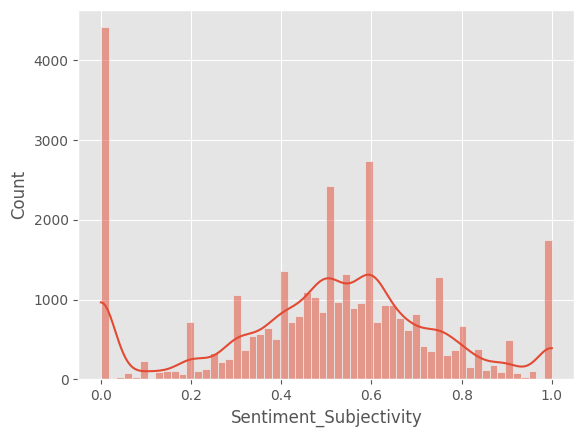

In [34]:
sns.histplot(
    review[
        'Sentiment_Subjectivity'
    ],
    kde=True
)

In [35]:
fig = px.bar(
    x=top_categories.index,
    y=top_categories.values,
    title="Top Categories"
)

fig.show()

In [36]:
fig = px.pie(
    values=sentiment_percentage.values,
    names=sentiment_percentage.index,
    title="Sentiment Distribution"
)

fig.show()

In [37]:
fig = px.scatter(
    df,
    x='Reviews',
    y='Installs',
    color='Category'
)

fig.show()

In [41]:
print("""
GOOGLE PLAY STORE ANALYSIS INSIGHTS

1. Family and Game categories dominate
the Play Store ecosystem.

2. Most apps maintain ratings above 4.0,
indicating generally positive user satisfaction.

3. Free applications significantly outnumber
paid applications.

4. Reviews and installs show a moderate
positive correlation.

5. Positive user sentiment accounts for
the majority of customer feedback.

6. Popular apps attract both strong positive
and negative opinions.

7. Sentiment analysis provides deeper
insight into user experience than ratings alone.

8. Understanding user feedback helps
developers improve app quality and retention.
""")


GOOGLE PLAY STORE ANALYSIS INSIGHTS

1. Family and Game categories dominate
the Play Store ecosystem.

2. Most apps maintain ratings above 4.0,
indicating generally positive user satisfaction.

3. Free applications significantly outnumber
paid applications.

4. Reviews and installs show a moderate
positive correlation.

5. Positive user sentiment accounts for
the majority of customer feedback.

6. Popular apps attract both strong positive
and negative opinions.

7. Sentiment analysis provides deeper
insight into user experience than ratings alone.

8. Understanding user feedback helps
developers improve app quality and retention.

